[2026-04-17 Fiddler](https://thefiddler.substack.com/p/have-you-heard-the-buzz)
====================

Fiddler
-------
There are 10 with 7 in the tens place.  There are an additional 9 with 7 in the ones place.
Then, of the remaining, the multiples of 7 are 14, 21, 28, 35, 42, 49, 56, 63, 84, 91, 98.

Counting them up gives 30.

Extra credit
------------
Consider $N = 10^n$.  There are
$10^{n-1} + 9\cdot10^{n-2} + 9^2\cdot10^{n-3} + \cdots + 9^{n-1} = \sum_{k=1}^n 9^{k-1}10^{n-k}$
numbers with the digit 7.

Since 7 and 10 have no common factors other than 1, I'll hypothesize that, of the remaining
$10^n - \sum_{k=1}^n 9^{k-1}10^{n-k}$ numbers, one seventh of them are multiples of 7.

Solving $\frac17 + \sum_{k=1}^n \frac{6\cdot9^{k-1}}{7\cdot10^k} = \frac12$,
or $\sum_{k=1}^n 9^{k-1}/10^k = 5/12$, should yield a rough estimate for $N$.

In [1]:
k = var('k')
f(n) = 1/7 + 6/7*sum(9^(k-1)/10^k, k, 1, n)
solve(f(n) == 1/2, n)

[10^n == 12/7*9^n]

In [2]:
numerical_approx(log(7/12)/log(9/10))

5.11573521985368

Looking at the buzz fraction for 1 to 10000, there are steps up at 70-79, 700-799, 7000-7999.

Based on $n > 5$, I'd expect the minimum $N$ to be in the step up at 700000-799999.

In [3]:
def have7(n):
    if n == 0:
        return False
    if n % 10 == 7:
        return True
    return have7(n // 10)

import functools

@functools.cache
def buzz(n):
    if n < 7:
        return 0
    b = buzz(n-1)
    if n % 7 == 0 or have7(n):
        return b+1
    return b

In [4]:
buzz(100) # check the fiddler result

30

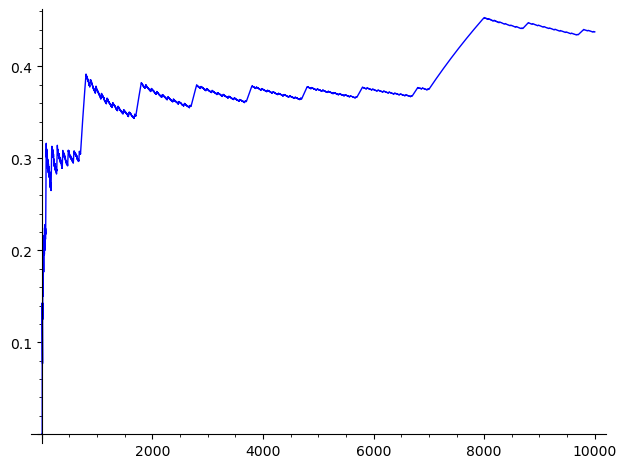

In [5]:
line([(i,buzz(i)/i) for i in [1..10000]])

In [6]:
[buzz(i*100) for i in [1..28000]] # load up the cache
i = 700000
while buzz(i)/i < 1/2:
    i += 1
i

708588

So the minimum $N = 708588$.  Checking after this and the next two steps, the
floor is more than 1/2 and increases with each step.

In [7]:
(numerical_approx(min([buzz(i)/i for i in [800000..1699999]])),
 numerical_approx(min([buzz(i)/i for i in [1800000..2699999]])),
 numerical_approx(min([buzz(i)/i for i in [2800000..3699999]])))

(0.521701878983548, 0.530243394640113, 0.534125817902548)